<a href="https://colab.research.google.com/github/tomz3302/Egyptian-Currency-Classifier/blob/RGB-Only/Egyptian_Currency_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Egyptian Currency Classification Project
**Team Members:** Omar Dardir & Roger Sherif
**Dataset:** [Egyptian New Currency 2023](https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023)

### Environment Setup
Run this cell to install dependencies and import libraries.

In [1]:
!pip install opendatasets

import os
from scipy.stats import skew
from google.colab import drive
import opendatasets as od
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib # For saving the model later
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from PIL import Image
import shutil

# Define where your images are based on your screenshot
base_dir2 = './egyptian-new-currency-2023-reorganized/dataset'
base_dir = './egyptian-new-currency-2023/dataset'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Common settings
IMG_SIZE = (224, 224) # Standard size for most models
BATCH_SIZE = 32

## Data Acquisition
In this section, we mount our shared Google Drive and download the currency images using the Kaggle API.

In [2]:

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project'

# This makes all your relative paths work from inside this folder
%cd {project_path}

# Verify where you are
!pwd

Mounted at /content/drive
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project


In [ ]:
dataset_folder = './egyptian-new-currency-2023'

if not os.path.exists(dataset_folder):
    print("Downloading dataset...")
    od.download("https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023")
else:
    print("Dataset already present in this session.")

Dataset already present in this session.


In [3]:
# 1. Define the name of your .7z file
archive_name = 'dataset_cleaned_split.7z' # <-- Replace with your actual file name

# 2. Define the new folder name
output_folder = 'egyptian-new-currency-2023-reorganized'

# 3. Create the directory if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Directory {output_folder} created.")

# 4. Extract the .7z file
# x: Extract with full paths
# -o: Specify output directory (Note: NO space between -o and the path)
!7z x {archive_name} -o{output_folder}

print(f"Extraction complete! Files are now in: {output_folder}")

Directory Egyptian_Currency_Classification_ML_Project_Reorganized created.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs AMD EPYC 7B12 (830F10),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 365589440 bytes (349 MiB)

Extracting archive: dataset_cleaned_split.7z
--
Path = dataset_cleaned_split.7z
Type = 7z
Physical Size = 365589440
Headers Size = 26468
Method = LZMA2:24
Solid = +
Blocks = 1

  0%      0% 15 - dataset_cleaned_split/train/100                                           0% 35 - dataset_cleaned_split/test/1/1.22.jpg                                                 0% 52 - dataset_cleaned_split/test/10/10.11.jpg

##Data Cleaning

In [9]:
def tf_aggressive_clean(directory):
    print(f"Scanning {directory} with TensorFlow decoder...")
    removed_count = 0
    scanned_count = 0

    # Walk through all folders
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            scanned_count += 1

            # 1. Delete "Ghost" files (common Mac/Windows transfer artifacts)
            if file.startswith("._") or file == ".DS_Store":
                try:
                    os.remove(file_path)
                    removed_count += 1
                    print(f"Removed system file: {file}")
                except:
                    pass
                continue

            # 2. Ask TensorFlow to decode it
            try:
                # Read the raw bytes
                file_contents = tf.io.read_file(file_path)

                # Try to decode (this mimics what dataset_from_directory does)
                # expand_animations=False fixes issues with some BMP/GIFs disguised as JPGs
                img = tf.io.decode_image(file_contents, channels=3, expand_animations=False)

                # Force execution to catch corrupt data
                # (TensorFlow is lazy, so we must inspect the shape to trigger the decode)
                if img.shape is None or img.shape[0] == 0:
                    raise ValueError("Empty image")

            except Exception as e:
                # If TF failed, delete the file
                print(f" Deleting corrupt file: {file} | Error: {e}")
                try:
                    os.remove(file_path)
                    removed_count += 1
                except:
                    print(f"Could not delete {file_path}")

    print(f"Scan complete. Scanned {scanned_count} files. Removed {removed_count} bad files.")

# Update these paths to match your Colab folder structure exactly
base_dir = './egyptian-new-currency-2023-reorganized/dataset'

tf_aggressive_clean(os.path.join(base_dir, 'train'))
tf_aggressive_clean(os.path.join(base_dir, 'valid'))
tf_aggressive_clean(os.path.join(base_dir, 'test'))

🔎 Scanning ./egyptian-new-currency-2023-reorganized/dataset/train with TensorFlow decoder...
🗑️ Deleting corrupt file: 100.10.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 200.98.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.29.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.43.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑

## Preprocessing
Before training, we need to:
1. Resize images to a uniform shape.
2. Normalize pixel values (0 to 1).
3. Split the data into Training and Validation sets.

In [3]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)
class_names = train_ds.class_names
print(f"Captured classes: {class_names}")

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)
class_names = val_ds.class_names
print(f"Captured classes: {class_names}")

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)
class_names = test_ds.class_names

# Normalize the pixels
# Each pixel has a value from 0 to 255 (0 is black, 255 is white)
# This turns pixel values like 255 into 1.0, making it easier for the model to learn color patterns.

#X is the images, Y is the labels
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 2631 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 756 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 287 files belonging to 9 classes.


## Data Exploration
Just a quick look at a few sample images to make sure our labels (5, 10, 20 EGP, etc.) match the pictures.

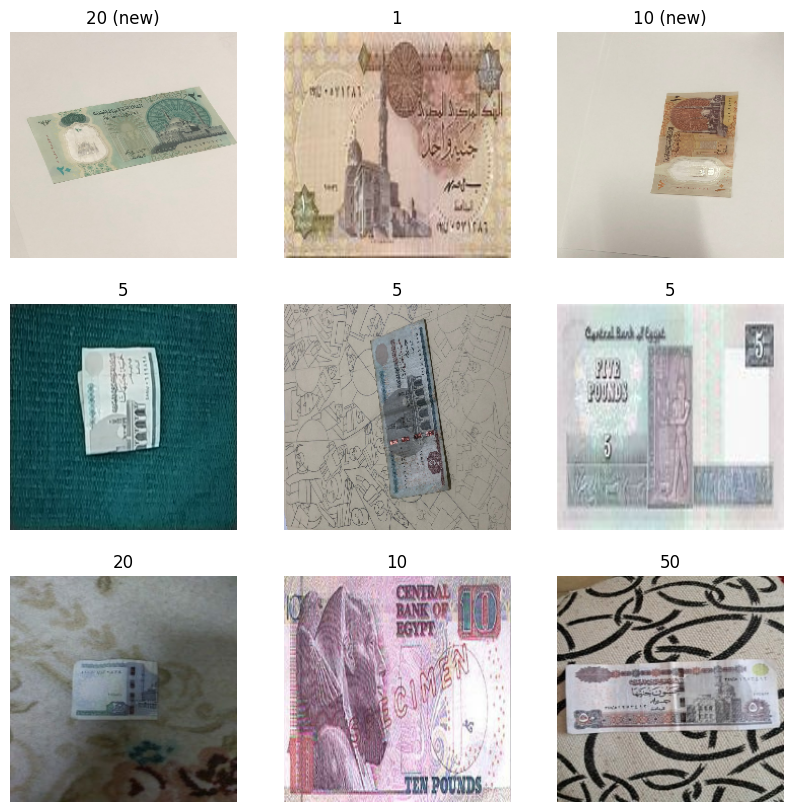

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        # We use the 'class_names' list we saved in the previous cell
        plt.title(class_names[labels[i]])
        plt.axis("off")

##Feature Extraction (HSV Histograms)

In [4]:
def extract_rgb_features_smart(dataset):
    features = []
    labels = []

    for images, batch_labels in dataset:
        for img, label in zip(images, batch_labels):
            # 1. Convert to 0-255 uint8
            img_uint8 = (img.numpy() * 255).astype('uint8')

            # 2. PREPROCESSING: Crop Center (Keep this, it helps)
            h, w, _ = img_uint8.shape
            margin_h = int(h * 0.1) # Reduced crop slightly (10%) to be safe
            margin_w = int(w * 0.1)
            center_crop = img_uint8[margin_h:h-margin_h, margin_w:w-margin_w]

            # We use the raw RGB values. If lighting is an issue,
            # normalization (done by the histogram) is usually enough for RGB.

            # --- FEATURE 1: 3D RGB Histogram (The "Fingerprint") ---
            # 8 bins per channel = 8x8x8 = 512 distinct color combinations.
            # This distinguishes "Reddish-Brown" (50 LE) from "Bright Orange" (10 LE)
            hist = cv2.calcHist([center_crop], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
            hist = cv2.normalize(hist, hist).flatten()

            # --- FEATURE 2: Simple Color Stats (Moments) ---
            # We keep these as backup info
            (R, G, B) = cv2.split(center_crop)
            means = [np.mean(R), np.mean(G), np.mean(B)]
            stds  = [np.std(R), np.std(G), np.std(B)]

            # Combine features
            # 512 (hist) + 6 (stats) = 518 features
            combined_features = np.hstack([hist, means, stds])

            features.append(combined_features)
            labels.append(label.numpy())

    return np.array(features), np.array(labels)

# Extract features
print("Extracting Training Features (Fixed)...")
X_train, y_train = extract_rgb_features_smart(train_ds)
X_val, y_val = extract_rgb_features_smart(val_ds)
X_test, y_test = extract_rgb_features_smart(test_ds)

print(f"Feature extraction complete. Feature vector size: {X_train.shape[1]}")

Extracting Training Features (Fixed)...
Feature extraction complete. Feature vector size: 518


## Model Training

In [5]:
# --------------------------------------------------------------------------
# PART 1: GRID SEARCH (Finding the best "Brain Structure")
# --------------------------------------------------------------------------

# We search for the best depth and learning speed.
# Note: We keep n_estimators small here just to compare models quickly.
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8],           # Fixed to save time
    'colsample_bytree': [0.8],    # Fixed to save time
    'n_estimators': [200]         # Fixed for search; we will boost this later
}

xgb_search = XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    tree_method='hist',
    random_state=42,
    reg_alpha=0.5,
    reg_lambda=5
)

print("1. Starting Grid Search to find best hyperparameters...")
grid_search = GridSearchCV(
    estimator=xgb_search,
    param_grid=param_grid,
    cv=3,                # 3-fold is faster and usually sufficient
    scoring='accuracy',
    verbose=1,
    n_jobs=-1            # Use all CPU cores
)

# We fit on X_train only for the search
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f"\nBest Parameters found: {best_params}")
print(f"Best Search Accuracy: {grid_search.best_score_ * 100:.2f}%")


# --------------------------------------------------------------------------
# PART 2: FINAL TRAINING (Finding the best "Training Time")
# --------------------------------------------------------------------------

print("\n2. Retraining with Best Parameters + Early Stopping...")

# We update the best parameters to allow for a longer training run
# We set n_estimators high (2000) but use Early Stopping to cut it short
final_params = best_params.copy()
final_params['n_estimators'] = 2000
final_params['early_stopping_rounds'] = 20  # Stop if no improvement for 20 rounds

# Initialize the final model with the winning parameters
best_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    tree_method='hist',
    random_state=42,
    reg_alpha=0.5,
    reg_lambda=5,
    **final_params  # Unpacks the dictionary: max_depth=4, learning_rate=0.1, etc.
)

# Fit using the validation set to trigger Early Stopping
best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50  # Print progress every 50 rounds
)

print(f"Final model stopped at epoch: {best_model.best_iteration}")
print("Training Complete.")

1. Starting Grid Search to find best hyperparameters...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best Search Accuracy: 82.55%

2. Retraining with Best Parameters + Early Stopping...
[0]	validation_0-mlogloss:1.91081	validation_1-mlogloss:1.94644
[50]	validation_0-mlogloss:0.10291	validation_1-mlogloss:0.46362
[100]	validation_0-mlogloss:0.03889	validation_1-mlogloss:0.38762
[150]	validation_0-mlogloss:0.02589	validation_1-mlogloss:0.36951
[200]	validation_0-mlogloss:0.02059	validation_1-mlogloss:0.36305
[250]	validation_0-mlogloss:0.01792	validation_1-mlogloss:0.36048
[300]	validation_0-mlogloss:0.01648	validation_1-mlogloss:0.35842
[311]	validation_0-mlogloss:0.01626	validation_1-mlogloss:0.35855
Final model stopped at epoch: 291
Training Complete.


# Evaluation
Testing the model on images it has never seen before to calculate the final accuracy.

Overall Accuracy: 89.02%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.95      0.95        20
          10       0.91      0.86      0.88        80
    10 (new)       0.94      0.92      0.93       130
         100       0.85      0.84      0.84        80
          20       0.93      0.88      0.90        80
    20 (new)       0.93      0.93      0.93       130
         200       0.86      0.91      0.88        79
           5       0.85      0.89      0.87        80
          50       0.80      0.83      0.82        77

    accuracy                           0.89       756
   macro avg       0.89      0.89      0.89       756
weighted avg       0.89      0.89      0.89       756



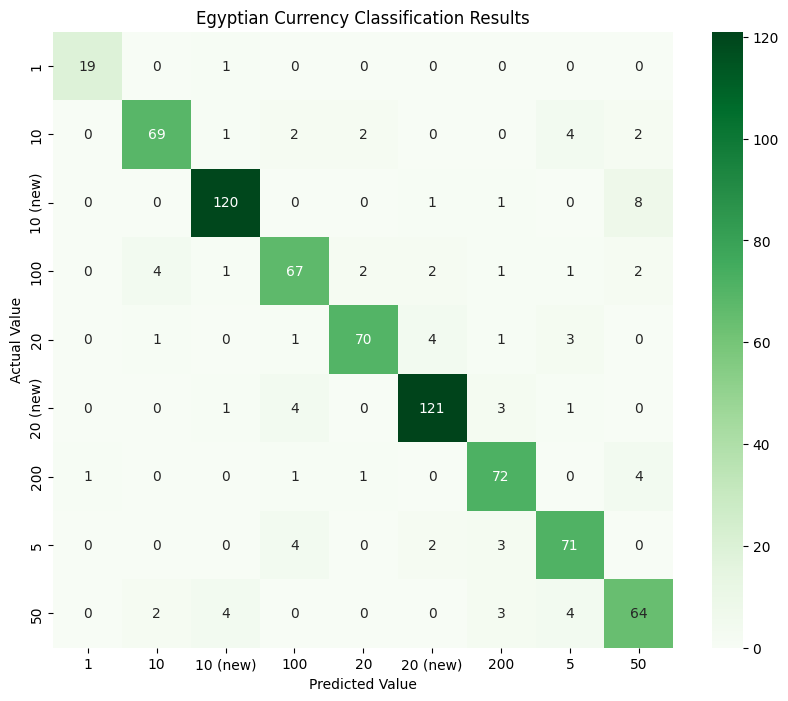

In [38]:
# Make predictions
y_pred = model.predict(X_val)

# Print Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# Detailed Report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# Visualize with a Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Egyptian Currency Classification Results')
plt.show()

Training Accuracy: 99.96%
------------------------------
Training Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60
          10       1.00      1.00      1.00       315
    10 (new)       1.00      1.00      1.00       317
         100       1.00      1.00      1.00       313
          20       1.00      1.00      1.00       322
    20 (new)       1.00      1.00      1.00       346
         200       1.00      1.00      1.00       313
           5       1.00      1.00      1.00       334
          50       1.00      1.00      1.00       311

    accuracy                           1.00      2631
   macro avg       1.00      1.00      1.00      2631
weighted avg       1.00      1.00      1.00      2631



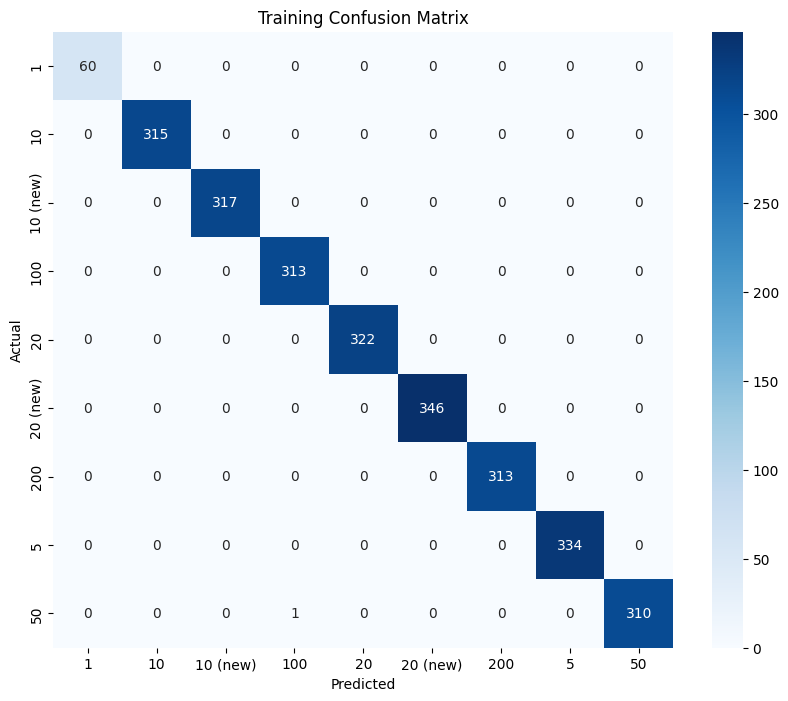

In [33]:
# ===== Evaluate on Training Data =====
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print("-" * 30)

print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=class_names))

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Confusion Matrix')
plt.show()


Test Accuracy: 88.50%
------------------------------
Test Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
          10       0.86      0.89      0.87        35
    10 (new)       0.91      1.00      0.95        30
         100       0.89      0.89      0.89        35
          20       1.00      0.77      0.87        35
    20 (new)       0.86      1.00      0.92        30
         200       0.82      0.77      0.79        35
           5       0.85      0.97      0.91        35
          50       0.86      0.75      0.80        32

    accuracy                           0.89       287
   macro avg       0.89      0.89      0.89       287
weighted avg       0.89      0.89      0.88       287



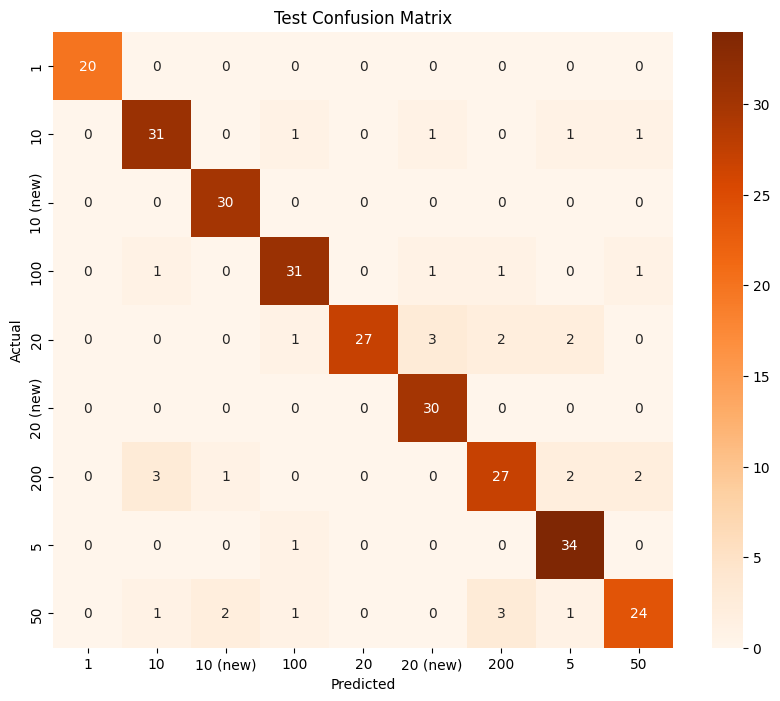

In [39]:
# ===== Evaluate on Test Data =====
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("-" * 30)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Oranges'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()
